In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from statsmodels.nonparametric.smoothers_lowess import lowess
import os


## GSE108539

In [102]:
# ----------------------------
# 1️⃣ Load data
# ----------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE108539/GSE108539_norm_reads_count.txt"
df = pd.read_csv(file_path, sep="\t")


In [103]:
print(df.columns)

Index(['Gene_name', 'Intron_15_S1_12.00', 'Intron_15_S2_16.00',
       'Intron_15_S3_20.00', 'Intron_15_S4_00.00', 'Intron_15_S5_04.00',
       'Intron_15_S6_08.00', 'Intron_3_S7_12.00', 'Intron_3_S8_16.00',
       'Intron_3_S9_20.00',
       ...
       'Exon_12_S51_20.00', 'Exon_12_S52_00.00', 'Exon_12_S53_04.00',
       'Exon_12_S54_08.00', 'Exon_1_S55_12.00', 'Exon_1_S56_16.00',
       'Exon_1_S57_20.00', 'Exon_1_S58_00.00', 'Exon_1_S59_04.00',
       'Exon_1_S60_08.00'],
      dtype='object', length=115)


Total Exon columns: 57
IGF2BP2 (Exon)
  Mesor     = -1.924
  Amplitude = 0.269
  Phase (h) = 1.04
[ 0.          0.06015038  0.12030075  0.18045113  0.2406015   0.30075188
  0.36090226  0.42105263  0.48120301  0.54135338  0.60150376  0.66165414
  0.72180451  0.78195489  0.84210526  0.90225564  0.96240602  1.02255639
  1.08270677  1.14285714  1.20300752  1.26315789  1.32330827  1.38345865
  1.44360902  1.5037594   1.56390977  1.62406015  1.68421053  1.7443609
  1.80451128  1.86466165  1.92481203  1.98496241  2.04511278  2.10526316
  2.16541353  2.22556391  2.28571429  2.34586466  2.40601504  2.46616541
  2.52631579  2.58646617  2.64661654  2.70676692  2.76691729  2.82706767
  2.88721805  2.94736842  3.0075188   3.06766917  3.12781955  3.18796992
  3.2481203   3.30827068  3.36842105  3.42857143  3.4887218   3.54887218
  3.60902256  3.66917293  3.72932331  3.78947368  3.84962406  3.90977444
  3.96992481  4.03007519  4.09022556  4.15037594  4.21052632  4.27067669
  4.33082707  4.39097744  4

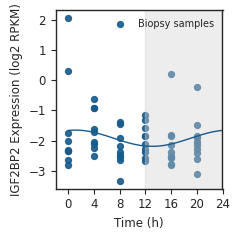

In [124]:
# ----------------------------
# 2️⃣ Extract gene (handle versions)
# ----------------------------
gene_id = "ENSG00000073792"

df["Gene_clean"] = df["Gene_name"].astype(str).str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# ----------------------------
# 3️⃣ Extract EXON columns only
# ----------------------------
import re

exon_cols = [col for col in df.columns if col.startswith("Exon_")]
print("Total Exon columns:", len(exon_cols))

times = []
values = []

for col in exon_cols:
    
    # Extract time from column name (last part)
    time_str = col.split("_")[-1]   # e.g. 12.00
    time = int(float(time_str))
    
    val = float(gene_row[col].values[0])
    
    times.append(time)
    values.append(val)

times = np.array(times)
values = np.array(values)

# Sort by time
order = np.argsort(times)
times = times[order]
values = values[order]

# ----------------------------
# 4️⃣ Cosinor model
# ----------------------------
from scipy.optimize import curve_fit

def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# ----------------------------
# 5️⃣ Plot
# ----------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

# RAW scatter (log2 RPKM)
plt.scatter(
    times,
    values,
    color="#185b8c",
    s=18,
    alpha=0.9,
    label="Biopsy samples"
)

# ----------------------------
# Cosinor fit (log2 scale)
# ----------------------------
M_guess = values.mean()
A_guess = (values.max() - values.min()) / 2
phi_guess = times[np.argmax(values)]

popt, _ = curve_fit(
    cosinor,
    times,
    values,
    p0=[M_guess, A_guess, phi_guess]
)

M, A, phi = popt

print("IGF2BP2 (Exon)")
print(f"  Mesor     = {M:.3f}")
print(f"  Amplitude = {A:.3f}")
print(f"  Phase (h) = {phi % 24:.2f}")

t_smooth = np.linspace(0, 24, 400)
y_smooth = cosinor(t_smooth, *popt)

plt.plot(
    t_smooth,
    y_smooth,
    color="#185b8c",
    linewidth=1
)

# print the x - values
print(t_smooth)

# ----------------------------
# Dark phase shading
# ----------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# ----------------------------
# Styling
# ----------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("IGF2BP2 Expression (log2 RPKM)", fontsize=8.5)

plt.xticks([0,4,8,12,16,20,24])
plt.xlim(-2,24)

plt.yticks(fontsize=8.5)

ax = plt.gca()
ax.tick_params(axis='both', left=True, bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7,loc="upper right")
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE108539/GSE108539_IGF2BP2_expression_fit.tiff", dpi=300,bbox_inches='tight', transparent=True  )
plt.show()

Total Exon columns: 57

Removed points (< -2):
Time = 0, Value = -2.662
Time = 0, Value = -2.345
Time = 0, Value = -2.307
Time = 0, Value = -2.341
Time = 0, Value = -2.013
Time = 0, Value = -2.821
Time = 4, Value = -2.514
Time = 4, Value = -2.112
Time = 4, Value = -2.259
Time = 4, Value = -2.042
Time = 8, Value = -2.467
Time = 8, Value = -2.385
Time = 8, Value = -2.649
Time = 8, Value = -2.556
Time = 8, Value = -3.327
Time = 8, Value = -2.177
Time = 12, Value = -2.274
Time = 12, Value = -2.106
Time = 12, Value = -2.592
Time = 12, Value = -2.379
Time = 12, Value = -2.686
Time = 16, Value = -2.134
Time = 16, Value = -2.528
Time = 16, Value = -2.562
Time = 16, Value = -2.804
Time = 16, Value = -2.396
Time = 16, Value = -2.578
Time = 16, Value = -2.774
Time = 20, Value = -3.123
Time = 20, Value = -2.601
Time = 20, Value = -2.053
Time = 20, Value = -2.290
Time = 20, Value = -2.408
Time = 20, Value = -2.151

IGF2BP2 (Exon)
  Mesor     = -1.144
  Amplitude = 0.542
  Phase (h) = 23.56


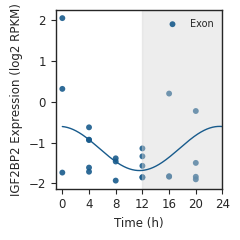

In [122]:
# ----------------------------
# 2️⃣ Extract gene (handle versions safely)
# ----------------------------
gene_id = "ENSG00000073792"

# Automatically detect first column as gene column
gene_col = df.columns[0]

df["Gene_clean"] = df[gene_col].astype(str).str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# ----------------------------
# 3️⃣ Extract EXON columns only
# ----------------------------
exon_cols = [col for col in df.columns if col.startswith("Exon_")]
print("Total Exon columns:", len(exon_cols))

times = []
values = []

for col in exon_cols:
    
    # Extract time from column name (last part)
    time_str = col.split("_")[-1]   # e.g. 12.00
    time = int(float(time_str))
    
    val = float(gene_row[col].values[0])
    
    times.append(time)
    values.append(val)

times = np.array(times)
values = np.array(values)

# ----------------------------
# 4️⃣ Sort by time
# ----------------------------
order = np.argsort(times)
times = times[order]
values = values[order]

# ----------------------------
# 5️⃣ Remove points < -2
# ----------------------------
original_times = times.copy()
original_values = values.copy()

mask = original_values >= -2

times = original_times[mask]
values = original_values[mask]

print("\nRemoved points (< -2):")
for t, v in zip(original_times[~mask], original_values[~mask]):
    print(f"Time = {t}, Value = {v:.3f}")

# ----------------------------
# 6️⃣ Cosinor model (24h)
# ----------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# Initial guesses
M_guess = values.mean()
A_guess = (values.max() - values.min()) / 2
phi_guess = times[np.argmax(values)]

popt, _ = curve_fit(
    cosinor,
    times,
    values,
    p0=[M_guess, A_guess, phi_guess]
)

M, A, phi = popt

print("\nIGF2BP2 (Exon)")
print(f"  Mesor     = {M:.3f}")
print(f"  Amplitude = {A:.3f}")
print(f"  Phase (h) = {phi % 24:.2f}")

# Smooth curve
t_smooth = np.linspace(0, 24, 400)
y_smooth = cosinor(t_smooth, *popt)

# ----------------------------
# 7️⃣ Plot
# ----------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

# RAW scatter (log2 RPKM)
plt.scatter(
    times,
    values,
    color="#185b8c",
    s=18,
    alpha=0.9,
    edgecolors='none',
    label="Exon"
)

# Cosinor fit
plt.plot(
    t_smooth,
    y_smooth,
    color="#185b8c",
    linewidth=1
)

# ----------------------------
# Dark phase shading
# ----------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# ----------------------------
# Styling (match your other plots)
# ----------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("IGF2BP2 Expression (log2 RPKM)", fontsize=8.5)

plt.xticks([0,4,8,12,16,20,24])
plt.xlim(-1,24)

plt.yticks(fontsize=8.5)

ax = plt.gca()
ax.tick_params(axis='both', left=True, bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7, loc="upper right")
plt.tight_layout()

plt.show()

In [111]:
# ----------------------------
# Extract EXON columns only
# ----------------------------
exon_cols = [col for col in df.columns if col.startswith("Exon_")]

times = []
values = []
samples = []

for col in exon_cols:
    
    # Extract time (last part of column name)
    time_str = col.split("_")[-1]     # e.g. 12.00
    time = int(float(time_str))
    
    val = float(gene_row[col].values[0])
    
    times.append(time)
    values.append(val)
    samples.append(col)   # store full sample name

times = np.array(times)
values = np.array(values)
samples = np.array(samples)

# Sort everything together
order = np.argsort(times)

times = times[order]
values = values[order]
samples = samples[order]

In [112]:
plot_df = pd.DataFrame({
    "Time (h)": times,
    "Expression (log2 RPKM)": values,
    "Sample": samples
})

print(plot_df)

    Time (h)  Expression (log2 RPKM)             Sample
0          0                1.543408   Exon_15_S4_00.00
1          0                1.097941   Exon_3_S10_00.00
2          0                1.861421   Exon_2_S16_00.00
3          0                1.362552   Exon_6_S22_00.00
4          0                1.670461   Exon_9_S34_00.00
5          0                0.693918   Exon_1_S58_00.00
6          0                1.260628   Exon_4_S46_00.00
7          0                1.569049  Exon_13_S40_00.00
8          0                2.030049  Exon_12_S52_00.00
9          4                0.544759   Exon_9_S35_04.00
10         4                0.569978   Exon_1_S59_04.00
11         4                0.821664  Exon_12_S53_04.00
12         4                0.869475   Exon_2_S17_04.00
13         4                1.091800   Exon_6_S23_04.00
14         4                1.192137   Exon_3_S11_04.00
15         4                0.830630   Exon_15_S5_04.00
16         4                0.898025  Exon_13_S4

## GSE182117

NGT_CTL
  Mesor     = 5.061
  Amplitude = -0.094
  Phase (h) = 13.33

NGT_HGI
  Mesor     = 5.084
  Amplitude = 0.074
  Phase (h) = 1.86

T2D_CTL
  Mesor     = 4.357
  Amplitude = -0.067
  Phase (h) = 13.33

T2D_HGI
  Mesor     = 4.314
  Amplitude = 0.056
  Phase (h) = 1.22



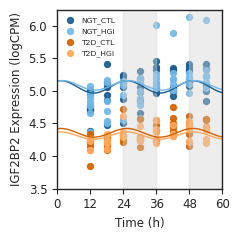

In [99]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE182117/GSE182117_logCPM_batchCorrected.tsv"
df = pd.read_csv(file_path, sep="\t")

# -------------------------
# 2️⃣ Extract gene
# -------------------------
gene_id = "ENSG00000073792"
df["Gene_clean"] = df["Tags"].str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Organize replicate-level data
# -------------------------
data_dict = {}
pattern = re.compile(r"(NGT|T2D)_(CTL|HGI)_(\d+)h_i\d+")

for col in df.columns:
    match = pattern.match(col)
    if match:
        group = f"{match.group(1)}_{match.group(2)}"
        time = int(match.group(3))
        
        if group not in data_dict:
            data_dict[group] = {"times": [], "values": []}
        
        value = float(gene_row[col].values[0])
        
        data_dict[group]["times"].append(time)
        data_dict[group]["values"].append(value)

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
from scipy.optimize import curve_fit

def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# Color control (EDIT HEX HERE)
# -------------------------
colors = {
    "NGT_CTL": "#185b8c",
    "NGT_HGI": "#73b7e7",
    "T2D_CTL": "#d16200",
    "T2D_HGI": "#ffa85c",
}

# -------------------------
# Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

groups_sorted = sorted(data_dict.keys())

for group in groups_sorted:
    
    times = np.array(data_dict[group]["times"])
    values = np.array(data_dict[group]["values"])
    
    order = np.argsort(times)
    times = times[order]
    values = values[order]
    
    if len(times) < 3:
        print(f"{group}: Not enough points for cosinor.\n")
        continue
    
    # -------------------------
    # RAW replicate scatter
    # -------------------------
    plt.scatter(
        times,
        values,
        color=colors[group],
        s=18,              # same dot size
        alpha=0.9,         # same transparency
        label=group
    )
    
    # -------------------------
    # Cosinor fit
    # -------------------------
    M_guess = values.mean()
    A_guess = (values.max() - values.min()) / 2
    phi_guess = times[np.argmax(values)]
    
    popt, _ = curve_fit(
        cosinor,
        times,
        values,
        p0=[M_guess, A_guess, phi_guess]
    )
    
    M, A, phi = popt
    
    print(f"{group}")
    print(f"  Mesor     = {M:.3f}")
    print(f"  Amplitude = {A:.3f}")
    print(f"  Phase (h) = {phi % 24:.2f}")
    print()
    
    t_smooth = np.linspace(0, 60, 500)
    y_smooth = cosinor(t_smooth % 24, *popt)
    
    plt.plot(
        t_smooth,
        y_smooth,
        color=colors[group],
        linewidth=1
    )

# -------------------------
# Dark phase shading (match previous style)
# -------------------------
plt.axvspan(24, 36, color="lightgray", alpha=0.4)
plt.axvspan(48, 60, color="lightgray", alpha=0.4)

# -------------------------
# Styling (match exactly)
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("IGF2BP2 Expression (logCPM)", fontsize=8.5)

plt.xticks(np.arange(0,61,12), fontsize=8.5)
plt.xlim(0,60)

plt.yticks(np.arange(3.5, 6.5, 0.5), fontsize=8.5)

ax = plt.gca()
ax.tick_params(axis='both', left=True, bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=5.5
           , handlelength=1.5)
plt.tight_layout()

plt.savefig(
"/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE182117/GSE182117_IGF2BP2_circadian_plot.tiff",
dpi=300,
bbox_inches='tight',
transparent=True
)

plt.show()

## with Z-score normalization

In [ ]:
# -------------------------
# 2️⃣ Extract gene
# -------------------------
gene_id = "ENSG00000133794"
df["Gene_clean"] = df["Tags"].str.split(".").str[0]
gene_row = df[df["Gene_clean"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Organize per individual
# -------------------------
pattern = re.compile(r"(NGT|T2D)_(CTL|HGI)_(\d+)h_(i\d+)")

# Structure:
# {group: {individual: {time: value}}}
data = {}

for col in df.columns:
    match = pattern.match(col)
    if match:
        group = f"{match.group(1)}_{match.group(2)}"
        time = int(match.group(3))
        individual = match.group(4)
        
        if group not in data:
            data[group] = {}
        if individual not in data[group]:
            data[group][individual] = {}
        
        value = float(gene_row[col].values[0])
        data[group][individual][time] = value

# 24h harmonic model
def cosinor(t, M, A, phi):
    return M + A * np.cos(2 * np.pi / 24 * (t - phi))

# -------------------------
# 4️⃣ Z-score per individual
# -------------------------
z_data = {}

for group in sorted(z_data.keys()):
    
    means = []
    sems = []
    times = []
    
    for t in sorted(z_data[group].keys()):
        vals = np.array(z_data[group][t])
        
        times.append(t)
        means.append(vals.mean())
        sems.append(vals.std() / np.sqrt(len(vals)))
    
    times = np.array(times)
    means = np.array(means)
    sems = np.array(sems)

    # -------------------------
    # Plot raw mean ± SEM
    # -------------------------
    plt.errorbar(
        times,
        means,
        yerr=sems,
        fmt='o',
        linewidth=1.5,
        markersize=5,
        capsize=3,
        color=colors[group],
        label=group
    )

    # -------------------------
    # Harmonic (cosinor) fit
    # -------------------------
    try:
        # Initial guesses
        M_guess = means.mean()
        A_guess = (means.max() - means.min()) / 2
        phi_guess = times[np.argmax(means)]

        popt, _ = curve_fit(
            cosinor,
            times,
            means,
            p0=[M_guess, A_guess, phi_guess]
        )

        # Smooth time grid
        t_smooth = np.linspace(0, 60, 300)
        y_smooth = cosinor(t_smooth, *popt)

        # Plot fitted curve
        plt.plot(
            t_smooth,
            y_smooth,
            color=colors[group],
            linewidth=2
        )

    except RuntimeError:
        print(f"Fit failed for {group}")

# -------------------------
# 5️⃣ Plot mean ± SEM of Z-scores
# -------------------------
sns.set_style("white")
plt.figure(figsize=(7,5))

colors = {
    "NGT_CTL": "black",
    "NGT_HGI": "#2C7BB6",
    "T2D_CTL": "#D7191C",
    "T2D_HGI": "#1A9641"
}

for group in sorted(z_data.keys()):
    
    means = []
    sems = []
    times = []
    
    for t in sorted(z_data[group].keys()):
        vals = np.array(z_data[group][t])
        
        times.append(t)
        means.append(vals.mean())
        sems.append(vals.std() / np.sqrt(len(vals)))
    
    times = np.array(times)
    means = np.array(means)
    sems = np.array(sems)
    
    print(group)
    print("Times:", times)
    print("Z-mean:", means)
    print()
    
    plt.errorbar(
        times,
        means,
        yerr=sems,
        fmt='o-',
        linewidth=2,
        markersize=5,
        capsize=3,
        color=colors[group],
        label=group
    )

# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(24, 36, color="lightgray", alpha=0.5)
plt.axvspan(48, 60, color="lightgray", alpha=0.5)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=12)
plt.ylabel("Z-score (log2CPM)", fontsize=12)

# add grid
plt.grid(True)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_linewidth(1.5)
plt.gca().spines["bottom"].set_linewidth(1.5)

plt.tick_params(width=1.5)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [6]:
# -------------------------
# 🔎 SANITY CHECK
# -------------------------

check_group = "NGT_CTL"   # change if needed
check_time = 12           # change if needed

print("\n================ SANITY CHECK ================\n")
print(f"Gene: {gene_id}")
print(f"Group: {check_group}")
print(f"Time: {check_time}h\n")

if check_group in data_dict and check_time in data_dict[check_group]:
    
    entries = data_dict[check_group][check_time]
    
    values = np.array([v for (_, v) in entries])
    columns = [c for (c, _) in entries]
    
    mean_val = values.mean()
    sd_val = values.std()
    sem_val = sd_val / np.sqrt(len(values))
    
    print("Columns used:")
    for c in columns:
        print("  ", c)
    
    print("\nValues used:")
    print(values)
    
    print("\nNumber of samples:", len(values))
    print(f"\nMean = {mean_val:.6f}")
    print(f"SD   = {sd_val:.6f}")
    print(f"SEM  = {sem_val:.6f}")
    
else:
    print("Group or timepoint not found.")
    
print("\n==============================================\n")


================ SANITY CHECK ================

Gene: ENSG00000133794
Group: NGT_CTL
Time: 12h

Columns used:
   NGT_CTL_12h_i01
   NGT_CTL_12h_i04
   NGT_CTL_12h_i12
   NGT_CTL_12h_i08
   NGT_CTL_12h_i09
   NGT_CTL_12h_i10
   NGT_CTL_12h_i11

Values used:
[4.7221444  4.94858438 5.01521521 4.71766286 4.68597496 4.76882238
 4.37731744]

Number of samples: 7

Mean = 4.747960
SD   = 0.190830
SEM  = 0.072127




## GSE194106

In [8]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE194106/GSE194106_RNAseq-muscle-tpm.txt"
df = pd.read_csv(file_path, sep="\t")


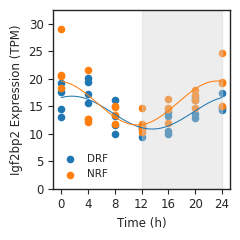

In [55]:
# -------------------------
# 2️⃣ Extract gene (Entrez ID)
# -------------------------
gene_id = "319765"
gene_row = df[df["geneID"].astype(str) == str(gene_id)]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Group raw TPM values
# -------------------------
pattern = re.compile(r"Gas([DN])(\d+)_\d+")

data_dict = {}

for col in df.columns:
    match = pattern.match(col)
    if match:
        group_letter = match.group(1)
        time = int(match.group(2))
        group = "DRF" if group_letter == "D" else "NRF"

        if group not in data_dict:
            data_dict[group] = []

        raw_value = float(gene_row[col].values[0])
        data_dict[group].append((time, raw_value))

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# 5️⃣ Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

c
cmap = plt.get_cmap("tab10")
groups_sorted = sorted(data_dict.keys())

for i, group in enumerate(groups_sorted):

    color = cmap(i)

    # Convert to arrays
    times = np.array([x[0] for x in data_dict[group]])
    values = np.array([x[1] for x in data_dict[group]])

    order = np.argsort(times)
    times = times[order]
    values = values[order]

    # Raw points
    plt.scatter(
        times,
        values,
        color=color,
        s=20,
        alpha=1,
        label=f"{group}"
    )

    # Harmonic fit
    try:
        M_guess = values.mean()
        A_guess = (values.max() - values.min()) / 2
        phi_guess = times[np.argmax(values)]

        popt, _ = curve_fit(
            cosinor,
            times,
            values,
            p0=[M_guess, A_guess, phi_guess]
        )

        t_smooth = np.linspace(0, 24, 300)
        y_smooth = cosinor(t_smooth, *popt)

        plt.plot(
            t_smooth,
            y_smooth,
            color=color,
            linewidth=0.75
        )

    except RuntimeError:
        print(f"Fit failed for {group}")
# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("Igf2bp2 Expression (TPM)", fontsize=8.5)

all_times = sorted(set([x[0] for g in data_dict.values() for x in g]))
plt.xticks(all_times)
plt.yticks(np.arange(0, 35, 2.5
                     ))


ax = plt.gca()

# Major ticks every 2.5
ax.yaxis.set_major_locator(MultipleLocator(5))

ax.tick_params(axis='both', left=True,bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7.5, handlelength=1.5, loc="best")
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE194106/GSE194106_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
plt.show()

## GSE212079 samples with complex genotypes - Ignored for the analysis

In [56]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE212079/GSE212079_Muscle_SCN_ARC_raw_count.tsv"
df = pd.read_csv(file_path, sep="\t")


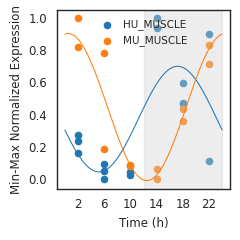

In [61]:

# -------------------------
# 2️⃣ Extract gene (Ensembl ID)
# -------------------------
gene_id = "ENSMUSG00000033581"  # <-- change this
gene_row = df[df["GENE_ID"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract only HU_MUSCLE and MU_MUSCLE
# -------------------------
pattern = re.compile(r"(HU|MU)_ZT(\d+)_\d+_MUSCLE")

data_dict = {}

for col in df.columns:
    match = pattern.match(col)
    if match:
        species = match.group(1)        # HU or MU
        time = int(match.group(2))
        group = f"{species}_MUSCLE"

        if group not in data_dict:
            data_dict[group] = []

        value = float(gene_row[col].values[0])
        data_dict[group].append((time, value))

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# 5️⃣ Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

cmap = plt.get_cmap("tab10")
groups_sorted = sorted(data_dict.keys())

for i, group in enumerate(groups_sorted):

    color = cmap(i)

    times = np.array([x[0] for x in data_dict[group]])
    values = np.array([x[1] for x in data_dict[group]])

    # Sort by time
    order = np.argsort(times)
    times = times[order]
    values = values[order]

    # -------------------------
    # Min-Max normalization (per group)
    # -------------------------
    vmin = values.min()
    vmax = values.max()

    if vmax - vmin == 0:
        norm_values = values
    else:
        norm_values = (values - vmin) / (vmax - vmin)

    # -------------------------
    # Plot normalized raw points
    # -------------------------
    plt.scatter(
        times,
        norm_values,
        color=color,
        s=20,
        alpha=1,
        label=group
    )

    # -------------------------
    # Harmonic fit
    # -------------------------
    try:
        M_guess = norm_values.mean()
        A_guess = (norm_values.max() - norm_values.min()) / 2
        phi_guess = times[np.argmax(norm_values)]

        popt, _ = curve_fit(
            cosinor,
            times,
            norm_values,
            p0=[M_guess, A_guess, phi_guess]
        )

        t_smooth = np.linspace(0, 24, 300)
        y_smooth = cosinor(t_smooth, *popt)

        plt.plot(
            t_smooth,
            y_smooth,
            color=color,
            linewidth=0.75
        )

    except RuntimeError:
        print(f"Fit failed for {group}")

# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("Min-Max Normalized Expression", fontsize=8.5)

all_times = sorted(set([x[0] for g in data_dict.values() for x in g]))
plt.xticks(all_times)

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.tick_params(axis='both', labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7.5, handlelength=1.5, loc="best")
plt.tight_layout()
plt.show()

## GSE308276

In [ ]:
# -------------------------
# 1️⃣ Load Excel
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE308276/GSE308276_FPKM_mus_from_WT_and_Bmal1LKO_6tp.xlsx"
df = pd.read_excel(file_path)


KO:
  Amplitude = 0.312
  Phase (h) = -0.83

WT:
  Amplitude = 0.374
  Phase (h) = 1.05



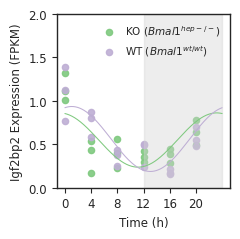

In [80]:

# -------------------------
# 2️⃣ Extract gene by symbol
# -------------------------
gene_symbol = "Igf2bp2"   # change if needed
gene_row = df[df["GeneSym"] == gene_symbol]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract WT and KO columns
# -------------------------
pattern = re.compile(r"(WT|KO)_ZT(\d+)_REP\d+")

data_dict = {}

for col in df.columns:
    match = pattern.search(col)
    if match:
        group = match.group(1)
        time = int(match.group(2))

        if group not in data_dict:
            data_dict[group] = []

        value = float(gene_row[col].values[0])
        data_dict[group].append((time, value))

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# 5️⃣ Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

cmap = plt.get_cmap("Accent")
groups_sorted = sorted(data_dict.keys())

for i, group in enumerate(groups_sorted):

    color = cmap(i)

    times = np.array([x[0] for x in data_dict[group]])
    values = np.array([x[1] for x in data_dict[group]])

    order = np.argsort(times)
    times = times[order]
    values = values[order]

    # -------------------------
    # Plot raw replicate points
    # -------------------------
    if group == "KO":
        legend_label = r"KO ($\it{Bmal1}^{hep-/-}$)"
    else:
        legend_label = r"WT ($\it{Bmal1}^{wt/wt}$)"

    plt.scatter(
        times,
        values,
        color=color,
        s=20,
        alpha=0.9,
        label=legend_label
    )
    # -------------------------
    # Harmonic regression fit
    # -------------------------
    try:
        M_guess = values.mean()
        A_guess = (values.max() - values.min()) / 2
        phi_guess = times[np.argmax(values)]

        popt, _ = curve_fit(
            cosinor,
            times,
            values,
            p0=[M_guess, A_guess, phi_guess]
        )

        t_smooth = np.linspace(0, 24, 300)
        y_smooth = cosinor(t_smooth, *popt)

        plt.plot(
            t_smooth,
            y_smooth,
            color=color,
            linewidth=0.75
        )

        M, A, phi = popt
        print(f"{group}:")
        print(f"  Amplitude = {A:.3f}")
        print(f"  Phase (h) = {phi:.2f}")
        print()

    except RuntimeError:
        print(f"Fit failed for {group}")

# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("Igf2bp2 Expression (FPKM)", fontsize=8.5)

all_times = sorted(set([x[0] for g in data_dict.values() for x in g]))
plt.xticks(all_times)

ax = plt.gca()

ax = plt.gca()

# Fix y-axis range
ax.set_ylim(0, 2)

# Set ticks from 0 to 1.5 in 0.25 steps
ax.set_yticks(np.arange(0, 2.1, 0.5))

ax.tick_params(axis='both', left=True,bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7.5, handlelength=1.5)
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE308276/GSE308276_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
plt.show()

## GSE273878


In [87]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE273878/GSE273878_gene_fpkm.xls"
df = pd.read_csv(file_path,sep="\t")


Amplitude = 0.101
Phase (h) = 4.43


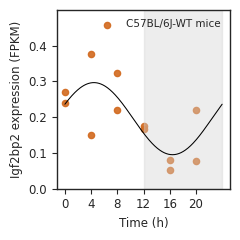

In [93]:

# -------------------------
# 2️⃣ Extract gene by Ensembl ID
# -------------------------
gene_id = "ENSMUSG00000033581"   # <-- replace with actual Ensembl ID
gene_row = df[df["gene_id"] == gene_id]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# 3️⃣ Extract SM columns
# -------------------------
pattern = re.compile(r"SM(\d+)_\d+")

data = []

for col in df.columns:
    match = pattern.match(col)
    if match:
        time = int(match.group(1))
        value = float(gene_row[col].values[0])
        data.append((time, value))

# Convert to arrays
times = np.array([x[0] for x in data])
values = np.array([x[1] for x in data])

# Sort
order = np.argsort(times)
times = times[order]
values = values[order]

# -------------------------
# 4️⃣ Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# 5️⃣ Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

# Raw replicate points
plt.scatter(
    times,
    values,
    color="chocolate",
    s=20,
    alpha=0.9,
    label="C57BL/6J-WT mice"
)

# Harmonic fit
try:
    M_guess = values.mean()
    A_guess = (values.max() - values.min()) / 2
    phi_guess = times[np.argmax(values)]

    popt, _ = curve_fit(
        cosinor,
        times,
        values,
        p0=[M_guess, A_guess, phi_guess]
    )

    t_smooth = np.linspace(0, 24, 300)
    y_smooth = cosinor(t_smooth, *popt)

    plt.plot(
        t_smooth,
        y_smooth,
        color="black",
        linewidth=0.75
    )

    M, A, phi = popt
    print(f"Amplitude = {A:.3f}")
    print(f"Phase (h) = {phi:.2f}")

except RuntimeError:
    print("Fit failed")

# -------------------------
# Dark phase shading
# -------------------------
plt.axvspan(12, 24, color="lightgray", alpha=0.4)

# -------------------------
# Styling
# -------------------------
plt.xlabel("Time (h)", fontsize=8.5)
plt.ylabel("Igf2bp2 expression (FPKM)", fontsize=8.5)

plt.xticks(sorted(set(times)))

ax = plt.gca()

# ✅ Fixed y-limits (adjust if needed)
ax.set_ylim(0, 0.5)

# Fixed y-ticks
ax.set_yticks(np.arange(0, 0.5, 0.1))

ax.tick_params(axis='both', left=True, bottom=True, labelsize=8.5)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.legend(frameon=False, fontsize=7.5)
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE273878/GSE273878_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
plt.show()

## GSE109825

In [65]:

# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE109825/GSE109825_invitro_rpkm_matrix_formated.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    index_col=False
)


In [66]:
# print row names top 5
print(df.index[:5])
print(df.columns[:5])

RangeIndex(start=0, stop=5, step=1)
Index(['#Ensembl_id', 'coordinates', 'gene_name', 'donor1_siClock_95_140505_2',
       'donor1_siCtrl_3_140505_2'],
      dtype='object')


In [67]:
print(df.head())

         #Ensembl_id                 coordinates    gene_name  \
0  ENSG00000225538.1   chr11:55850277-55851215:+      OR5BE1P   
1  ENSG00000237851.1  chr6:143109260-143115223:+  RP1-67K17.4   
2  ENSG00000212855.5      chrY:9578193-9596085:+        TTTY2   
3  ENSG00000257527.1   chr16:18505166-18505708:-    MIR3179-3   
4  ENSG00000225193.5   chr15:90749804-90750199:+     RPS12P26   

   donor1_siClock_95_140505_2  donor1_siCtrl_3_140505_2  \
0                    0.000000                  0.000000   
1                    0.000000                  0.000000   
2                    0.000000                  0.000000   
3                    0.000000                  0.000000   
4                    0.539201                  1.495345   

   donor1_siClock51_140313_4  donor1_siClock53_140313_7  \
0                   0.000000                   0.000000   
1                   0.000000                   0.000000   
2                   0.000000                   0.000000   
3                 

Donor1_siCtrl
  Mesor     = 3.375
  Amplitude = 0.203
  Phase (h) = 19.01
Donor2_siCtrl
  Mesor     = 3.338
  Amplitude = 0.066
  Phase (h) = 21.22
Donor1_siClock
  Mesor     = 3.509
  Amplitude = 0.154
  Phase (h) = 20.61
Donor2_siClock
  Mesor     = 3.451
  Amplitude = -0.016
  Phase (h) = 3.49


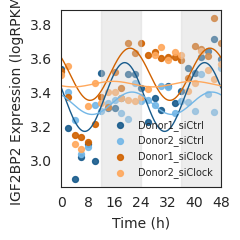

In [68]:
# -------------------------
# Extract gene
# -------------------------
gene_symbol = "IGF2BP2"

df["gene_name"] = df["gene_name"].astype(str).str.strip().str.upper()
gene_row = df[df["gene_name"] == gene_symbol]

if gene_row.empty:
    raise ValueError("Gene not found.")

# -------------------------
# Cosinor model
# -------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# -------------------------
# Time maps
# -------------------------

siCtrl_map = {
    0: ["donor1_siCtrl1_140313_6", "donor2_siCtrl1_140313_8"],
    2: ["donor1_siCtrl_3_140505_2", "donor2_siCtrl3_140313_4"],
    4: ["donor1_siCtrl5_140313_6", "donor2_siCtrl5_140313_8"],
    6: ["donor1_siCtrl7_140313_5", "donor2_siCtrl7_140313_3"],
    8: ["donor1_siCtrl9_140313_5", "donor2_siCtrl9_140313_3"],
    10:["donor1_siCtrl11_140313_7","donor2_siCtrl11_140313_1"],
    12:["donor1_siCtrl13_140313_6","donor2_siCtrl13_140313_1"],
    14:["donor1_siCtrl15_140313_5","donor2_siCtrl15_140313_2"],
    16:["donor1_siCtrl17_140313_6","donor2_siCtrl17_140313_4"],
    18:["donor1_siCtrl19_140313_8","donor2_siCtrl19_140313_6"],
    20:["donor1_siCtrl21_140313_6","donor2_siCtrl_21_140505_1"],
    22:["donor1_siCtrl23_140313_2","donor2_siCtrl23_140313_2"],
    24:["donor1_siCtrl25_140313_6","donor2_siCtrl25_140313_2"],
    26:["donor1_siCtrl27_140313_6","donor2_siCtrl27_140313_1"],
    28:["donor1_siCtrl29_140313_5","donor2_siCtrl29_140313_3"],
    30:["donor1_siCtrl31_140313_7","donor2_siCtrl31_140313_1"],
    32:["donor1_siCtrl33_140313_8","donor2_siCtrl33_140313_4"],
    34:["donor1_siCtrl35_140313_5","donor2_siCtrl35_140313_2"],
    36:["donor1_siCtrl37_140313_5","donor2_siCtrl37_140313_3"],
    38:["donor1_siCtrl39_140313_5","donor2_siCtrl39_140313_8"],
    40:["donor1_siCtrl41_140313_5","donor2_siCtrl41_140313_4"],
    42:["donor1_siCtrl43_140313_5","donor2_siCtrl43_140313_4"],
    44:["donor1_siCtrl45_140313_7","donor2_siCtrl45_140313_1"],
    46:["donor1_siCtrl47_140313_7","donor2_siCtrl47_140313_1"],
    48:["donor1_siCtrl49_140313_6","donor2_siCtrl49_140313_3"],
}

siClock_map = {
    0:["donor1_siClock51_140313_4","donor2_siClock51_140313_8"],
    2:["donor1_siClock53_140313_7","donor2_siClock53_140313_1"],
    4:["donor1_siClock55_140313_6","donor2_siClock55_140313_1"],
    6:["donor1_siClock57_140313_1","donor2_siClock57_140313_2"],
    8:["donor1_siClock59_140313_8","donor2_siClock59_140313_4"],
    10:["donor1_siClock61_140313_8","donor2_siClock61_140313_7"],
    12:["donor1_siClock63_140313_6","donor2_siClock63_140313_3"],
    14:["donor1_siClock65_140313_6","donor2_siClock65_140313_2"],
    16:["donor1_siClock67_140313_7","donor2_siClock67_140313_4"],
    18:["donor1_siClock69_140313_7","donor2_siClock69_140313_1"],
    20:["donor1_siClock71_140313_5","donor2_siClock71_140313_4"],
    22:["donor1_siClock73_140313_5","donor2_siClock73_140313_1"],
    24:["donor1_siClock75_140313_7","donor2_siClock75_140313_3"],
    26:["donor1_siClock77_140313_3","donor2_siClock_77_140505_2"],
    28:["donor1_siClock79_140313_7","donor2_siClock79_140313_4"],
    30:["donor1_siClock81_140313_8","donor2_siClock81_140313_3"],
    32:["donor1_siClock83_140313_3","donor2_siClock83_140313_2"],
    34:["donor1_siClock85_140313_1","donor2_siClock85_140313_8"],
    36:["donor1_siClock87_140313_8","donor2_siClock87_140313_2"],
    38:["donor1_siClock89_140313_7","donor2_siClock89_140313_4"],
    40:["donor1_siClock91_140313_5","donor2_siClock91_140313_4"],
    42:["donor1_siClock93_140313_2","donor2_siClock93_140313_2"],
    44:["donor1_siClock_95_140505_2","donor2_siClock95_140313_3"],
    46:["donor1_siClock97_140313_8","donor2_siClock97_140313_2"],
    48:["donor1_siClock99_140313_7","donor2_siClock99_140313_3"],
}

# -------------------------
# Color control (EDIT HEX HERE)
# -------------------------
colors = {
    "Donor1_siCtrl": "#185b8c",
    "Donor2_siCtrl": "#73b7e7",
    "Donor1_siClock": "#d16200",
    "Donor2_siClock": "#ffa85c",
}

# -------------------------
# Plot
# -------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))
groups = [
    ("Donor1_siCtrl", siCtrl_map, 0),
    ("Donor2_siCtrl", siCtrl_map, 1),
    ("Donor1_siClock", siClock_map, 0),
    ("Donor2_siClock", siClock_map, 1),
]

for label, mapping, donor_idx in groups:

    times = []
    values = []

    for t, cols in mapping.items():
        val = float(gene_row[cols[donor_idx]].values[0])
        times.append(t)
        values.append(np.log2(val + 1e-6))  # log2 RPKM

    times = np.array(times)
    values = np.array(values)

    order = np.argsort(times)
    times = times[order]
    values = values[order]

    plt.scatter(times, values, color=colors[label], s=18, alpha=0.9, label=label)

    # Cosinor fit
    M_guess = values.mean()
    A_guess = (values.max() - values.min()) / 2
    phi_guess = times[np.argmax(values)]

    popt, _ = curve_fit(
    cosinor,
    times,
    values,
    p0=[M_guess, A_guess, phi_guess]
)

    M, A, phi = popt

    print(f"{label}")
    print(f"  Mesor     = {M:.3f}")
    print(f"  Amplitude = {A:.3f}")
    print(f"  Phase (h) = {phi % 24:.2f}")

    t_smooth = np.linspace(0,48,500)
    y_smooth = cosinor(t_smooth % 24, *popt)

   

    plt.plot(t_smooth, y_smooth,
             color=colors[label],
             linewidth=1)

# Dark phase
plt.axvspan(12,24,color="lightgray",alpha=0.4)
plt.axvspan(36,48,color="lightgray",alpha=0.4)

plt.xlabel("Time (h)")
plt.ylabel("IGF2BP2 Expression (logRPKM)")
plt.xticks(np.arange(0,49,8))
# plt.grid(True)
plt.xlim(0,48)
plt.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE109825/GSE109825_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
plt.show()

In [76]:
# -----------------------------
# 3️⃣ Build rename dictionary
# -----------------------------
rename_dict = {}

for time, samples in siCtrl_map.items():
    rename_dict[samples[0]] = f"donor_1_siControl_ZT{time}"
    rename_dict[samples[1]] = f"donor_2_siControl_ZT{time}"

for time, samples in siClock_map.items():
    rename_dict[samples[0]] = f"donor_1_siClock_ZT{time}"
    rename_dict[samples[1]] = f"donor_2_siClock_ZT{time}"

# -----------------------------
# Rename columns
# -----------------------------
df_rename = df.rename(columns=rename_dict)

# -----------------------------
# Identify metadata columns
# -----------------------------
meta_cols = []

for col in df_rename.columns:
    if not col.startswith("donor_"):
        meta_cols.append(col)

# This will automatically keep:
# Ensembl_ID, gene_name, or any other annotation columns

# -----------------------------
# Build ordered sample columns
# -----------------------------
zt_points = sorted(siCtrl_map.keys())

sample_cols = []

# siControl first
for zt in zt_points:
    sample_cols.append(f"donor_1_siControl_ZT{zt}")
    sample_cols.append(f"donor_2_siControl_ZT{zt}")

# siClock next
for zt in zt_points:
    sample_cols.append(f"donor_1_siClock_ZT{zt}")
    sample_cols.append(f"donor_2_siClock_ZT{zt}")

# -----------------------------
# Combine metadata + ordered samples
# -----------------------------
final_cols = meta_cols + sample_cols

df_ordered = df_rename[final_cols]


In [77]:

# -----------------------------
# Save
# -----------------------------
output_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE109825/GSE109825_renamed.tsv"

df_ordered.to_csv(output_path, sep="\t", index=False)

print("File saved successfully.")

File saved successfully.


## GSE107787

In [134]:
# -------------------------
# 1️⃣ Load data
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE107787/GSE107787_RNAseq_expression_results.xlsx"

df = pd.read_excel(
    file_path,
    engine='openpyxl',
    index_col= False
)



In [135]:
# print the column names
print(df.columns.tolist())

df.head()

['Gene', 'Muscle_FED_ZT00_Rep3', 'Muscle_FED_ZT00_Rep4', 'Muscle_FED_ZT00_Rep5', 'Muscle_FED_ZT04_Rep1', 'Muscle_FED_ZT04_Rep3', 'Muscle_FED_ZT04_Rep5', 'Muscle_FED_ZT08_Rep2', 'Muscle_FED_ZT08_Rep3', 'Muscle_FED_ZT08_Rep5', 'Muscle_FED_ZT12_Rep1', 'Muscle_FED_ZT12_Rep3', 'Muscle_FED_ZT12_Rep5', 'Muscle_FED_ZT16_Rep1', 'Muscle_FED_ZT16_Rep4', 'Muscle_FED_ZT16_Rep5', 'Muscle_FED_ZT20_Rep1', 'Muscle_FED_ZT20_Rep2', 'Muscle_FED_ZT20_Rep5', 'Muscle_FAST_ZT00_Rep1', 'Muscle_FAST_ZT00_Rep3', 'Muscle_FAST_ZT00_Rep5', 'Muscle_FAST_ZT04_Rep2', 'Muscle_FAST_ZT04_Rep4', 'Muscle_FAST_ZT04_Rep5', 'Muscle_FAST_ZT08_Rep3', 'Muscle_FAST_ZT08_Rep4', 'Muscle_FAST_ZT08_Rep5', 'Muscle_FAST_ZT12_Rep2', 'Muscle_FAST_ZT12_Rep3', 'Muscle_FAST_ZT12_Rep5', 'Muscle_FAST_ZT16_Rep1', 'Muscle_FAST_ZT16_Rep2', 'Muscle_FAST_ZT16_Rep5', 'Muscle_FAST_ZT20_Rep1', 'Muscle_FAST_ZT20_Rep2', 'Muscle_FAST_ZT20_Rep5', 'Liver_FED_ZT00_Rep1', 'Liver_FED_ZT00_Rep3', 'Liver_FED_ZT00_Rep5', 'Liver_FED_ZT04_Rep2', 'Liver_FED_ZT04_R

,Gene,Muscle_FED_ZT00_Rep3,Muscle_FED_ZT00_Rep4,Muscle_FED_ZT00_Rep5,Muscle_FED_ZT04_Rep1,Muscle_FED_ZT04_Rep3,Muscle_FED_ZT04_Rep5,Muscle_FED_ZT08_Rep2,Muscle_FED_ZT08_Rep3,Muscle_FED_ZT08_Rep5,...,Liver_FAST_ZT08_Rep3,Liver_FAST_ZT12_Rep2,Liver_FAST_ZT12_Rep4,Liver_FAST_ZT12_Rep5,Liver_FAST_ZT16_Rep3,Liver_FAST_ZT16_Rep4,Liver_FAST_ZT16_Rep5,Liver_FAST_ZT20_Rep1,Liver_FAST_ZT20_Rep4,Liver_FAST_ZT20_Rep5
0,Xkr4,0.01147,0.01125,0.00000,0.01147,0.01210,0.01199,0.04127,0.02384,0.00000,...,0.00000,0.00000,0.00000,0.00942,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,Rp1,0.04275,0.06528,0.06363,0.01710,0.02255,0.04458,0.01736,0.05251,0.04058,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2,Sox17,1.72219,1.37552,1.89178,1.40962,1.17231,1.00325,1.97658,1.83654,1.57538,...,0.21660,0.23098,0.24574,0.28039,0.23745,0.23305,0.22616,0.20099,0.25505,0.21298
3,Mrpl15,11.43258,13.26742,12.50647,16.05910,12.84987,13.68800,12.81013,13.17235,12.08941,...,13.36675,16.40413,16.02372,19.32739,13.13610,13.54880,12.54656,12.32539,12.88261,13.11569
4,Lypla1,38.52326,34.19680,43.05566,41.50928,33.78573,27.47940,33.40592,43.68035,39.46907,...,72.35158,69.03459,63.10146,47.90502,91.24694,69.62924,73.31782,65.59976,64.09866,67.69408


Muscle_FED
  Mesor     = 0.603
  Amplitude = 0.417
  Phase (h) = 0.09

Muscle_FAST
  Mesor     = 0.508
  Amplitude = 0.072
  Phase (h) = 5.04



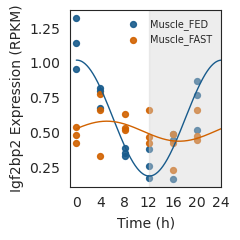

In [144]:
# ----------------------------
# 2️⃣ Extract gene row
# ----------------------------
gene_symbol = "IGF2BP2"

df["Gene"] = df["Gene"].astype(str).str.strip().str.upper()
gene_row = df[df["Gene"] == gene_symbol]
if gene_row.empty:
    raise ValueError("Gene not found.")

# ----------------------------
# 3️⃣ Cosinor model (24h)
# ----------------------------
def cosinor(t, M, A, phi):
    return M + A * np.cos(2*np.pi/24 * (t - phi))

# ----------------------------
# 4️⃣ Select Muscle columns only
# ----------------------------
muscle_cols = [c for c in df.columns if c.startswith("Muscle_")]

# Separate FED and FAST
groups = {
    "Muscle_FED": [],
    "Muscle_FAST": []
}

for col in muscle_cols:
    if "FED" in col:
        groups["Muscle_FED"].append(col)
    elif "FAST" in col:
        groups["Muscle_FAST"].append(col)

# ----------------------------
# 5️⃣ Plot
# ----------------------------
sns.set_style("white")
plt.figure(figsize=(2.5,2.5))

colors = {
    "Muscle_FED": "#185b8c",
    "Muscle_FAST": "#d16200"
}

for label, cols in groups.items():

    times = []
    values = []

    for col in cols:
        # Extract ZT time
        match = re.search(r"ZT(\d+)", col)
        if match:
            time = int(match.group(1))
        else:
            continue
        
        val = float(gene_row[col].values[0])
        
        times.append(time)
        values.append(val)   # already log-scale if dataset is logCPM/logRPKM

    times = np.array(times)
    values = np.array(values)

    # Sort by time
    order = np.argsort(times)
    times = times[order]
    values = values[order]

    # RAW scatter
    plt.scatter(
        times,
        values,
        color=colors[label],
        s=18,
        alpha=0.9,
        label=label
    )

    # ----------------------------
    # Cosinor fit
    # ----------------------------
    if len(times) >= 3:

        M_guess = values.mean()
        A_guess = (values.max() - values.min()) / 2
        phi_guess = times[np.argmax(values)]

        popt, _ = curve_fit(
            cosinor,
            times,
            values,
            p0=[M_guess, A_guess, phi_guess]
        )

        M, A, phi = popt

        print(f"{label}")
        print(f"  Mesor     = {M:.3f}")
        print(f"  Amplitude = {A:.3f}")
        print(f"  Phase (h) = {phi % 24:.2f}\n")

        t_smooth = np.linspace(0,24,400)
        y_smooth = cosinor(t_smooth, *popt)

        plt.plot(
            t_smooth,
            y_smooth,
            color=colors[label],
            linewidth=1
        )

# ----------------------------
# Dark phase shading
# ----------------------------
plt.axvspan(12,24,color="lightgray",alpha=0.4)

# ----------------------------
# Styling (match your format)
# ----------------------------
plt.xlabel("Time (h)")
plt.ylabel("Igf2bp2 Expression (RPKM)")
plt.xticks([0,4,8,12,16,20,24])
plt.xlim(-1,24)

plt.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE107787/GSE107787_IGF2BP2_expression.tiff", dpi=300,bbox_inches='tight',transparent=True)
plt.show()